# **Outliers Detection**



In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [45]:
df=pd.read_csv('/content/drive/MyDrive/Machine Learning/Python codes/Python Libraries Basics/placement.csv')
df.sample(10)

,cgpa,placement_exam_marks,placed
138,7.53,8.0,1
598,7.59,27.0,1
703,7.04,41.0,0
784,6.19,19.0,0
794,6.24,17.0,1
533,7.19,15.0,0
276,6.96,46.0,0
50,6.20,18.0,1
911,7.45,36.0,1
923,6.52,10.0,0


The skewness of CGPA is: -0.014529938929314918
The skewness of placement exam marks is: 0.8356419499466834


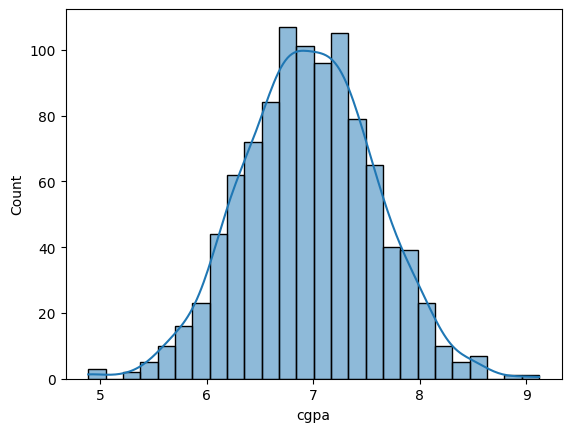

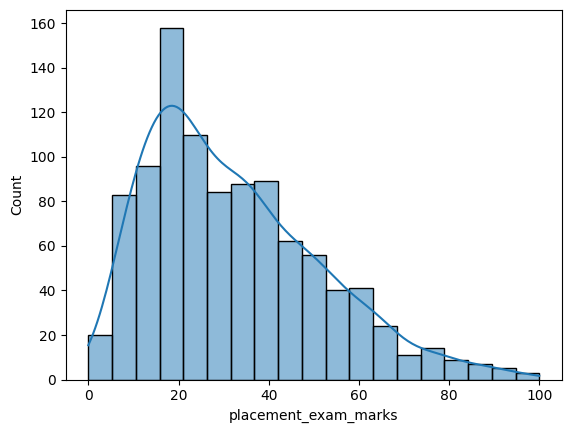

In [46]:
print("The skewness of CGPA is:", df['cgpa'].skew())
print("The skewness of placement exam marks is:", df['placement_exam_marks'].skew())

sns.histplot(df['cgpa'], kde=True)
plt.show()

sns.histplot(df['placement_exam_marks'], kde=True)
plt.show()

# **Outlier Detection Using Z-Score**

In [47]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [48]:
# Finding the outlier
outlier=df[(df['cgpa']<df['cgpa'].mean()-3*df['cgpa'].std())|(df['cgpa']>df['cgpa'].mean()+3*df['cgpa'].std())]
outlier

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# **Trimming**


In [49]:
trim_df=df[(df['cgpa']>df['cgpa'].mean()-3*df['cgpa'].std())&(df['cgpa']<df['cgpa'].mean()+3*df['cgpa'].std())]
trim_df.sample(5)

,cgpa,placement_exam_marks,placed
994,6.48,63.0,0
282,6.43,44.0,1
784,6.19,19.0,0
461,7.39,12.0,0
283,7.09,87.0,0


In [50]:
# Checking if any outlier is there in trim_df
outlier=trim_df[(trim_df['cgpa']<df['cgpa'].mean()-3*df['cgpa'].std())|(trim_df['cgpa']>df['cgpa'].mean()+3*df['cgpa'].std())]
outlier.shape

(0, 3)

# **Capping**

In [51]:
mn=df['cgpa'].mean()
sd=df['cgpa'].std()

upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [52]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [54]:
#finding the outliers
outlier=df[(df['cgpa']<mn-3*sd)|(df['cgpa']>mn+3*sd)]
outlier.shape

(0, 3)